#####    Data Description The Haberman's survival dataset contains cases from a study that was conducted between 1958 and 1970 at the University of Chicago's Billings Hospital on the survival of patients who had undergone surgery for breast cancer.

### Attribute Information:
    - Age of patient at time of operation (numerical)
    - Patient's year of operation (year - 1900, numerical)
    - Number of positive axillary nodes detected (numerical)
    - Survival status (class attribute) 1 = the patient survived 5 years or longer 2 = the patient died within 5 years

In [41]:
# import important moduls : 

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# load the dataset : 
cancer_df = pd.read_csv ( 'haberman.csv', header = None, names = ['Age', 'Year_of_treatment', 'Positive_lymph_nodes', 'Survival_status_after_5_years']) 

## Data preparation : 

In [19]:
cancer_df.head()

,Age,Year_of_treatment,Positive_lymph_nodes,Survival_status_after_5_years
0,30,64,1,1
1,30,62,3,1
2,30,65,0,1
3,31,59,2,1
4,31,65,4,1


In [20]:
cancer_df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 4 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Age                            306 non-null    int64
 1   Year_of_treatment              306 non-null    int64
 2   Positive_lymph_nodes           306 non-null    int64
 3   Survival_status_after_5_years  306 non-null    int64
dtypes: int64(4)
memory usage: 9.7 KB


### Observations    
    - There are no missing values in this dataset. So there is no need to do data imputation.
    - The datatype of 'survival_status_after_5_years' column is integer. It has to be converted to categorical datatype.
    - The values of 'survival_status_after_5_years' column are not meanigful. Hence they are mapped to 'yes' (survived after 5 years) and 'no' (not survived after 5 years)

In [24]:
# available values in survival status feature : 
cancer_df['Survival_status_after_5_years'].unique()

['Yes', 'No']
Categories (2, object): ['No', 'Yes']

In [22]:
# modify the target column values to be meaningful as well as categorical
cancer_df['Survival_status_after_5_years'] = cancer_df['Survival_status_after_5_years'].map({1: 'Yes', 2: 'No'}) .astype('category')
cancer_df.head()

,Age,Year_of_treatment,Positive_lymph_nodes,Survival_status_after_5_years
0,30,64,1,Yes
1,30,62,3,Yes
2,30,65,0,Yes
3,31,59,2,Yes
4,31,65,4,Yes


In [23]:
cancer_df.describe()

,Age,Year_of_treatment,Positive_lymph_nodes
count,306.000000,306.000000,306.000000
mean,52.457516,62.852941,4.026144
std,10.803452,3.249405,7.189654
min,30.000000,58.000000,0.000000
25%,44.000000,60.000000,0.000000
50%,52.000000,63.000000,1.000000
75%,60.750000,65.750000,4.000000
max,83.000000,69.000000,52.000000


In [37]:
print('number of rows :' + str(cancer_df.shape[0]))
print('number of columns:' + str(cancer_df.shape[1]))
print("column's name : " , ', '.join( cancer_df.columns))
print("       Columns: " + ", ".join(cancer_df.columns))
print( '*'*40 ) 
print('target variable distribution') 
print( cancer_df['Survival_status_after_5_years'].value_counts())
print( '*'*40 ) 
print( cancer_df.iloc[:,-1].value_counts())
print('*'*40, '\n normalize value' ) 
print( cancer_df.iloc[:,-1].value_counts(normalize = True))

number of rows :306
number of columns:4
column's name :  Age, Year_of_treatment, Positive_lymph_nodes, Survival_status_after_5_years
       Columns: Age, Year_of_treatment, Positive_lymph_nodes, Survival_status_after_5_years
****************************************
target variable distribution
Survival_status_after_5_years
Yes    225
No      81
Name: count, dtype: int64
****************************************
Survival_status_after_5_years
Yes    225
No      81
Name: count, dtype: int64
**************************************** 
 normalize value
Survival_status_after_5_years
Yes    0.735294
No     0.264706
Name: proportion, dtype: float64


### Observations:
    - The age of the patients vary from 30 to 83 with the median of 52.
    - Although the maximum number of positive lymph nodes observed is 52, nearly 75% of the patients have less than 5 positive lymph nodes and nearly 25% of the patients have no positive lymph nodes
    - The dataset contains only a small number of records (306).
    - The target column is imbalanced with 73% of values are 'yes'

## Univariate Analysis

### Distribution plots
    - Distribution plots are used to visually assess how the data points are distributed with respect to its frequency.
    - Usually the data points are grouped into bins and the height of the bars representing each group increases with increase in the number of data points /////lie within that group. (histogram)
    - Probality Density Function (PDF) is the probabilty that the variable takes a value x. (smoothed version of the histogram)
    - Kernel Density Estimate (KDE) is the way to estimate the PDF. The area under the KDE curve is 1.
    - Here the height of the bar denotes the percentage of data points under the corresponding group

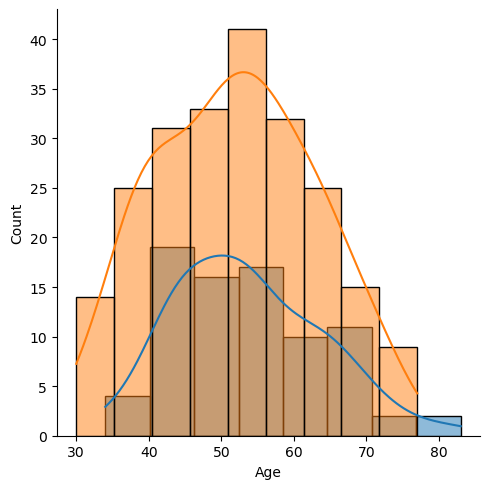

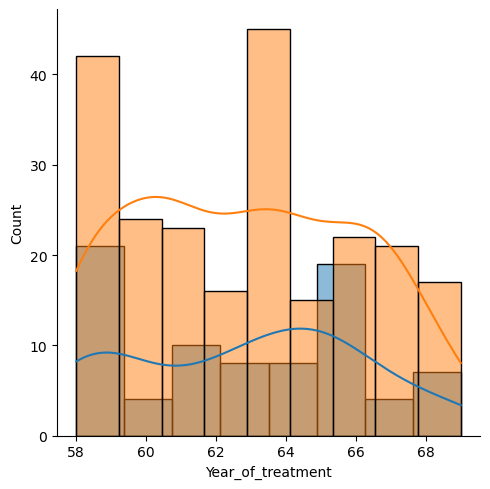

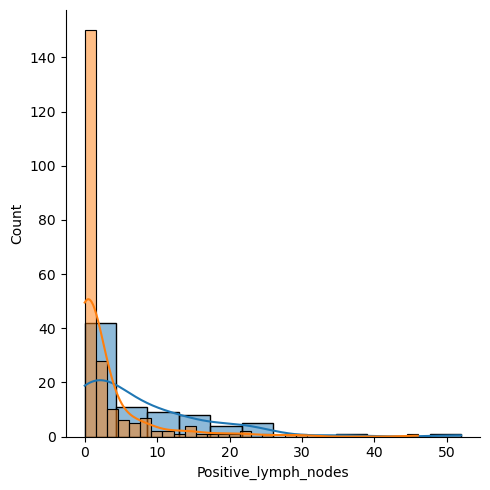

In [55]:
for idx, feature in enumerate(list(cancer_df.columns)[:-1]):
    fg = sns.FacetGrid(cancer_df, hue='Survival_status_after_5_years',height = 5)
    fg.map(sns.histplot, feature, kde = True )
    fig.add_legend()
    plt.show()

### CDF
    The cumulative distribution function (cdf) is the probability that the variable takes a value less than or equal to x.

***********Age***********
bin_edges : [30.  35.3 40.6 45.9 51.2 56.5 61.8 67.1 72.4 77.7 83. ]
pdf: [0.05228758 0.08823529 0.1503268  0.17320261 0.17973856 0.13398693
 0.13398693 0.05882353 0.02287582 0.00653595]
cdf: [0.05228758 0.14052288 0.29084967 0.46405229 0.64379085 0.77777778
 0.91176471 0.97058824 0.99346405 1.        ]
***********Year_of_treatment***********
bin_edges : [58.  59.1 60.2 61.3 62.4 63.5 64.6 65.7 66.8 67.9 69. ]
pdf: [0.20588235 0.09150327 0.08496732 0.0751634  0.09803922 0.10130719
 0.09150327 0.09150327 0.08169935 0.07843137]
cdf: [0.20588235 0.29738562 0.38235294 0.45751634 0.55555556 0.65686275
 0.74836601 0.83986928 0.92156863 1.        ]
***********Positive_lymph_nodes***********
bin_edges : [ 0.   5.2 10.4 15.6 20.8 26.  31.2 36.4 41.6 46.8 52. ]
pdf: [0.77124183 0.09803922 0.05882353 0.02614379 0.02941176 0.00653595
 0.00326797 0.         0.00326797 0.00326797]
cdf: [0.77124183 0.86928105 0.92810458 0.95424837 0.98366013 0.99019608
 0.99346405 0.99346405

C:\Users\amans\AppData\Local\Temp\ipykernel_21748\2051465127.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


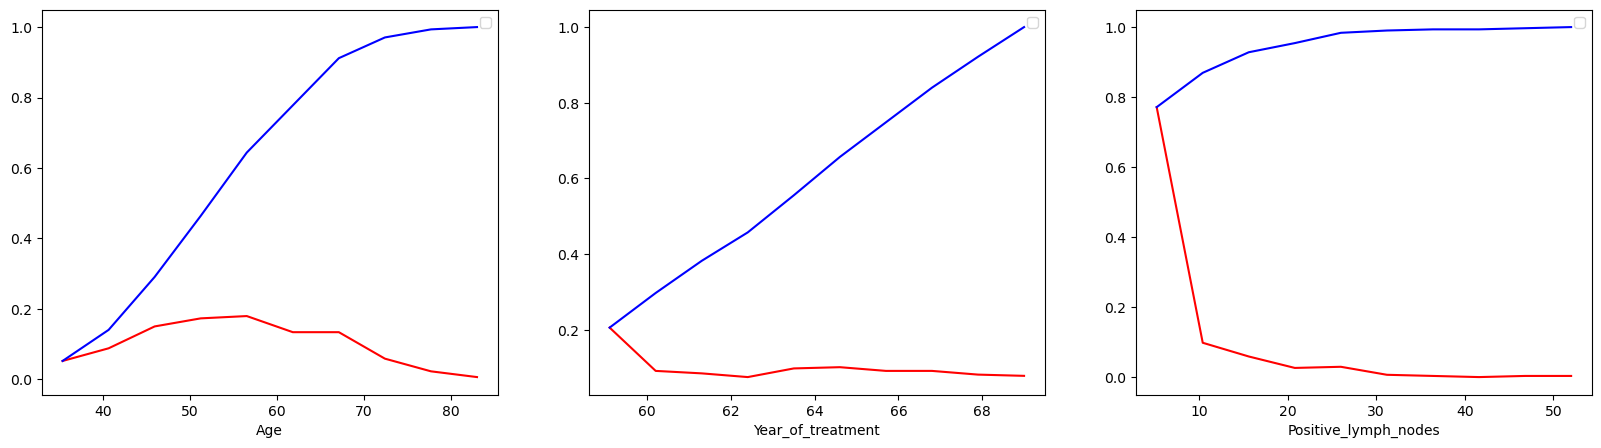

In [80]:
plt.figure( figsize = (20,5))
for idx, feature in enumerate(list(cancer_df.columns)[:-1]): 
    plt.subplot(1,3, idx+1)
    print('***********' + feature+ '***********')
    counts, bin_edges = np.histogram( cancer_df[feature], bins = 10 , density = True ) 
    print (f'bin_edges : { bin_edges}' )
    pdf = counts/ sum(counts)
    print(f'pdf: { pdf}')
    cdf = np.cumsum(pdf) 
    print(f'cdf: {cdf}') 
    plt.plot(bin_edges[1:], pdf, 'r', bin_edges[1:], cdf, 'b')
    plt.legend()
    plt.xlabel( feature) 

### Box Plots
    Box plot takes a less space and visually represents the five number summary of the data points in a box. 
        
    The outliers are displayed as points outside the box.
    1. Q1 - 1.5*IQR
    2. Q1 (25th percentile)
    3. Q2 (50th percentile or median)
    4. Q3 (75th percentile)
    5. Q3 + 1.5*IQR
    Inter Quartile Range = Q3 -Q1

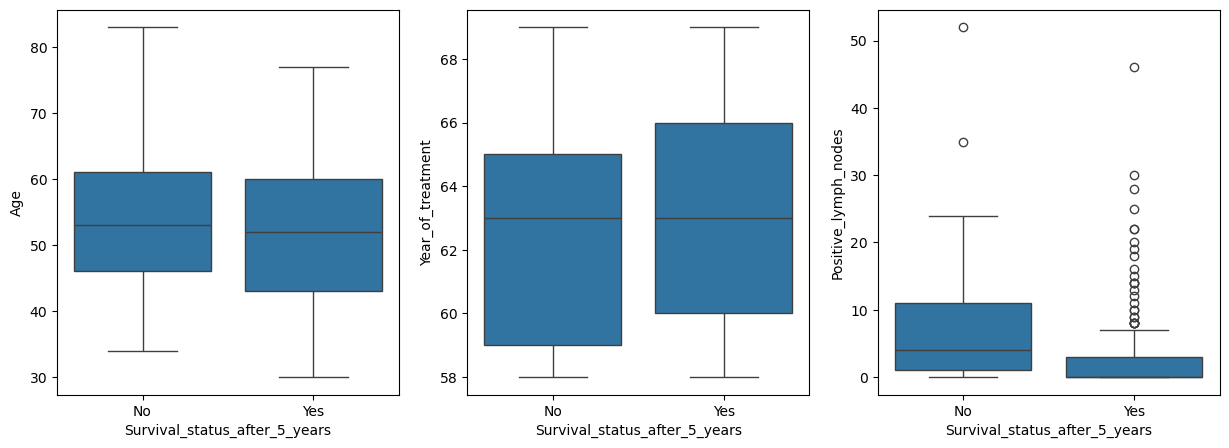

In [86]:
fig, axes = plt.subplots( 1, 3 , figsize = ( 15, 5 ))
for idx , feature in enumerate( list( cancer_df. columns)[:-1]):
    sns.boxplot( x = 'Survival_status_after_5_years' , y = feature , data = cancer_df  , ax = axes[idx]) 
plt.show()

### Violin Plots
    Violin plot is the combination of box plot and probability density function.

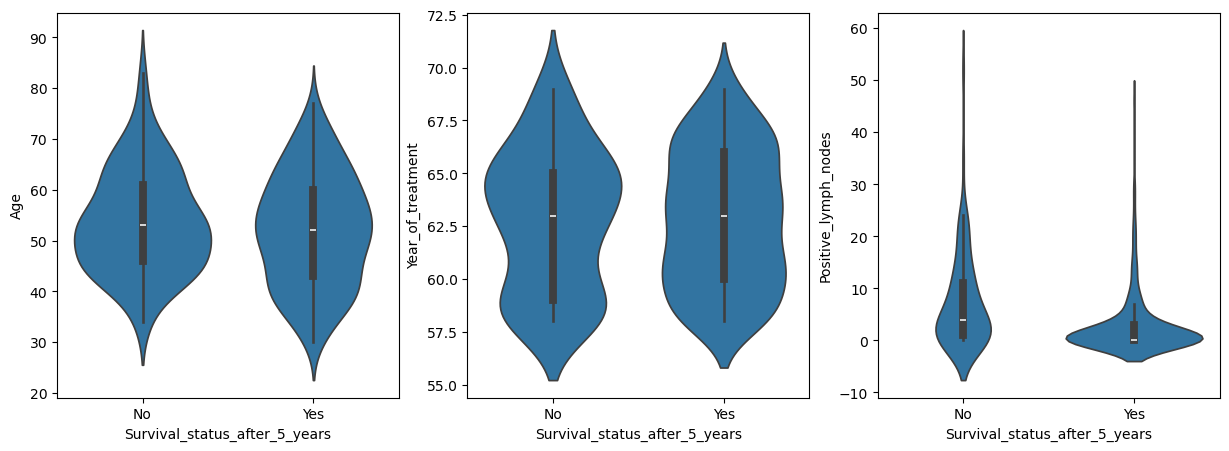

In [92]:
fig, axes = plt.subplots( 1,3 , figsize = (15, 5, ))
for idx, feature in enumerate ( list( cancer_df.columns)[:-1]) : 
    sns.violinplot( x = 'Survival_status_after_5_years', y = feature , data = cancer_df, ax = axes[idx])
plt.show()

### Observations  -
The number of positive lymph nodes of the survivors is highly densed from 0 to 5. (#5.1)
    Almost 80% of the patients have less than or equal to 5 positive lymph nodea. (#5.2)
    The patients treated after 1966 have the slighlty higher chance to surive that the rest. The patients treated before 1959 have the slighlty lower chance to surive that the rest. (#5.3 and #5.4)

## Multivariate Analysis

### pair plot
    Pair plot in seaborn plots the scatter plot between every two data columns in a given dataframe.
    It is used to visualize the relationship between two variables

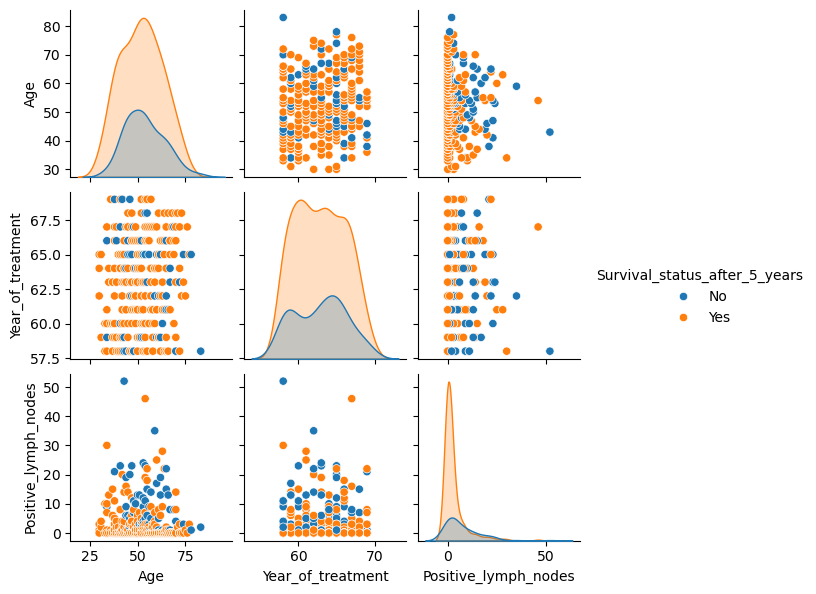

In [97]:
sns.pairplot( cancer_df, hue= 'Survival_status_after_5_years', height = 2 ) 
plt.show()

### Observations¶
    By scattering the data points between year_of_treatment and positive_lymph_nodes, we can see the better seperation between the two clases than other scatter plots.